
## About Dataset
Context
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

## Content
What's inside is more than just rows and columns. Make it easy for others to get started by describing how you acquired the data and what time period it represents, too.

Most important features that have an impact on Product taken: Designation, Passport, Tier City, Martial status, occupation
Customers with Designation as Executive should be the target customers for the company .Customers who have passport and are from tier 3 city and are single or unmarried, have large business such customers have higher chances of taking new package.
Customers monthly income in range of 15000- 25000, and age range 15-30, prefer 5 star properties also have higher chances of taking new package based on EDA.
### Inspiration
We need to analyze the customers' data and information to provide recommendations to the Policy Maker and Marketing Team and also build a model to predict the potential customer who is going to purchase the newly introduced travel package.

## Tasks to Solve :
To predict which customer is more likely to purchase the newly introduced travel package
Which variables are most significant.
Which segment of customers should be targeted more. (That means we have to classify)

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [118]:
df = pd.read_csv('Travel.csv')

In [119]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Data Cleaning

### 1. Handle Missing Values
### 2. Handling Duplicates
### 3. Check data type
### 4. Understand the dataset

In [120]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [121]:
df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [122]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [123]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

In [124]:
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')

In [125]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [126]:
## Check Missing Values
## These are the features with nan values
features_with_na = [features for features in df.columns if df[features].isnull().sum() > 0]

for feature in features_with_na:
  print(feature, np.round(df[feature].isnull().mean()*100, 5), '% missing values')


Age 4.62357 % missing values
TypeofContact 0.51146 % missing values
DurationOfPitch 5.13502 % missing values
NumberOfFollowups 0.92062 % missing values
PreferredPropertyStar 0.53191 % missing values
NumberOfTrips 2.86416 % missing values
NumberOfChildrenVisiting 1.35025 % missing values
MonthlyIncome 4.76678 % missing values


In [127]:
# statistics on numerical columns (Null cols)
df[features_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


# Imputing Null values

#### 1. Impute Median Value for Age column
#### 2. Impute Mode Value for TypeofContact column
#### 3. Impute Median Value for DurationOfPitch column
#### 4. Impute Mode Value for NumberOfFollowups column as it is Discrete feature
#### 5.  Impute Mode Value for PreferredPropertyStar column
#### 6. Impute Median Value for NumberOfTrips column
#### 7. Impute Mode Value for NumberOfChildrenVisiting column
#### 8. Impute Median Value for MonthlyIncome column

In [128]:
df.Age.fillna(df.Age.median(), inplace = True)

df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace = True)

df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace = True)

df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace = True)

df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace = True)

df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace = True)

df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace = True)

df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace = True)


In [129]:
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [130]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [131]:
df.drop('CustomerID', inplace=True, axis=1)

In [132]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


# Feature Engineering

## Feature Extraction

In [133]:
df['TotalVisiting'] = df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting']
df = df.drop(columns=['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'], axis=1)
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [134]:
num_features = [feature for feature in df.columns if df[feature].dtype != "O"] ## 'O' = Object
print('Num of Numerical features : ', len(num_features))

Num of Numerical features :  12


In [135]:
cat_features = [feature for feature in df.columns if df[feature].dtype == "O"] ## 'O' = Object
print('Num of Categorical features : ', len(cat_features))

Num of Categorical features :  6


In [136]:
discrete_features = [feature for feature in num_features if len(df[feature].unique()) <= 25]
print('Num of Discrete features : ', len(discrete_features))

Num of Discrete features :  9


In [137]:
continuous_features = [feature for feature in num_features if len(df[feature].unique()) > 25]
print('Num of Continuous features : ', len(continuous_features))

Num of Continuous features :  3


# Model Training

In [138]:
from sklearn.model_selection import train_test_split

X = df.drop(['ProdTaken'], axis=1)
y = df['ProdTaken']

In [139]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [140]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [141]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((3910, 17), (978, 17))

## Handling Categorical features

In [142]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4888 non-null   float64
 1   TypeofContact           4888 non-null   object 
 2   CityTier                4888 non-null   int64  
 3   DurationOfPitch         4888 non-null   float64
 4   Occupation              4888 non-null   object 
 5   Gender                  4888 non-null   object 
 6   NumberOfFollowups       4888 non-null   float64
 7   ProductPitched          4888 non-null   object 
 8   PreferredPropertyStar   4888 non-null   float64
 9   MaritalStatus           4888 non-null   object 
 10  NumberOfTrips           4888 non-null   float64
 11  Passport                4888 non-null   int64  
 12  PitchSatisfactionScore  4888 non-null   int64  
 13  OwnCar                  4888 non-null   int64  
 14  Designation             4888 non-null   

### We see above "object" is for categorical data, while rest are for numerical

In [143]:
## Create Column Transformer with 3 types of transformers

cat_features = X.select_dtypes(include = "object").columns
num_features = X.select_dtypes(exclude = "object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler  ## One-hot is used for >2 categories
from sklearn.compose import ColumnTransformer

numeric_tansformer = StandardScaler()
oh_transformer = OneHotEncoder(drop = 'first') ## if n columns then we need (n-1) columns by one-hot encoding thus drop 'first'

preprocessor = ColumnTransformer(
  [
    ("OneHotEncoder", oh_transformer, cat_features),
    ("StandardScaler", numeric_tansformer, num_features)
  ]
)


In [144]:
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(drop='first'),
                                 Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')),
                                ('StandardScaler', StandardScaler(),
                                 Index(['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups',
       'PreferredPropertyStar', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting'],
      dtype='object'))])

In [145]:
## Apply transformer
X_train = preprocessor.fit_transform(X_train)

In [149]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [ ]:
X_test = preprocessor.transform(X_test) ## not fit_tranform() due to data leakage

In [150]:
pd.DataFrame(X_test)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,-0.287333,1.284279,-0.725271,-1.220627,-0.632399,-0.777720,-1.277194,-0.737510,-0.774151
1,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.366823,-0.531672,0.282777,0.522885,-1.220627,1.581280,1.408395,-1.277194,-0.670411,-0.065268
2,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,0.812193,0.282777,-0.725271,0.965153,-0.632399,1.408395,0.782966,-0.420832,-0.774151
3,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,-0.721400,2.522566,2.285781,-0.725271,1.511598,-0.632399,-0.049015,0.782966,-0.113658,0.643615
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,-1.020350,0.282777,0.522885,-0.127737,1.581280,0.679690,0.782966,-0.317047,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,-0.725271,1.511598,-0.632399,1.408395,0.782966,0.498219,0.643615
974,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.142519,0.282777,1.771041,-0.674182,1.581280,-1.506426,-1.277194,-1.184015,-1.483035
975,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,1.056532,1.284279,-0.725271,-0.674182,1.581280,1.408395,0.782966,0.690012,0.643615
976,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.287333,-2.721728,-0.725271,-0.674182,-0.632399,1.408395,0.782966,-0.228278,-0.774151


# Random Forest Classifier

In [164]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score

In [165]:
models = {
  "Random Forest" : RandomForestClassifier(),
  "Decision Tree" : DecisionTreeClassifier(),
  "Logistic Regression" : LogisticRegression()
}

In [166]:
for i in range(len(list(models))):
   ## Train model
   model = list(models.values())[i]
   model.fit(X_train, y_train)

   ## Make predicitons
   y_train_pred = model.predict(X_train)
   y_test_pred = model.predict(X_test)

   ## Training set performance
   model_train_accuracy = accuracy_score(y_train, y_train_pred)
   model_train_f1 = f1_score(y_train, y_train_pred, average="weighted")
   model_train_precision = precision_score(y_train, y_train_pred)
   model_train_recall = recall_score(y_train, y_train_pred)
   model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)

   ## Test set performance
   model_test_accuracy = accuracy_score(y_test, y_test_pred)
   model_test_f1 = f1_score(y_test, y_test_pred, average="weighted")
   model_test_precision = precision_score(y_test, y_test_pred)
   model_test_recall = recall_score(y_test, y_test_pred)
   model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)

   print(list(models.keys())[i])

   print('Model performance for Training Set')

   print("- Accuracy : {:.4f}".format(model_train_accuracy))
   print("- F1 score: {:.4f}".format(model_train_f1))
   print("- Precision: {:.4f}".format(model_train_precision))
   print("- Recall : {:.4f}".format(model_train_recall))
   print("- Roc Auc Score : {:.4f}".format(model_train_rocauc_score))

   print("-"*35)

   print('Model performance for Test Set')

   print("- Accuracy : {:.4f}".format(model_test_accuracy))
   print("- F1 score: {:.4f}".format(model_test_f1))
   print("- Precision: {:.4f}".format(model_test_precision))
   print("- Recall : {:.4f}".format(model_test_recall))
   print("- Roc Auc Score : {:.4f}".format(model_test_rocauc_score))
   
   print('='*35)
   print('\n')

Random Forest
Model performance for Training Set
- Accuracy : 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall : 1.0000
- Roc Auc Score : 1.0000
-----------------------------------
Model performance for Test Set
- Accuracy : 0.9264
- F1 score: 0.9204
- Precision: 0.9685
- Recall : 0.6440
- Roc Auc Score : 0.8194


Decision Tree
Model performance for Training Set
- Accuracy : 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall : 1.0000
- Roc Auc Score : 1.0000
-----------------------------------
Model performance for Test Set
- Accuracy : 0.9182
- F1 score: 0.9179
- Precision: 0.7968
- Recall : 0.7801
- Roc Auc Score : 0.8659


Logistic Regression
Model performance for Training Set
- Accuracy : 0.8458
- F1 score: 0.8200
- Precision: 0.6994
- Recall : 0.3032
- Roc Auc Score : 0.6366
-----------------------------------
Model performance for Test Set
- Accuracy : 0.8354
- F1 score: 0.8078
- Precision: 0.6829
- Recall : 0.2932
- Roc Auc Score : 0.6301




In [ ]:
## Hyperparameter Tuning
{
  "max_depth" : [5, 8, 15, None, 10],
  "max_features" : [5, 7, "auto", 8],
  "min_samples_split" : [2, 8, 15, 20],
  "n_estimators" : [100, 200, 500, 1000]
}

In [173]:
# Models List for Hyperparameter tuning
randomcv_models = [
  ("RF", RandomForestClassifier(), rf_params)
]

In [174]:
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(
      estimator=model,
      param_distributions=params,
      n_iter=100,
      cv=3,
      verbose=2,
      n_jobs=-1
    )

    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
  print(f"=============== Best Params for {model_name} =============================")
  print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
=============== Best Params for RF =============================
{'n_estimators': 1000, 'min_samples_split': 2, 'max_features': 7, 'max_depth': 15}


In [179]:
models = {
  "Random Classifer":RandomForestClassifier(
    n_estimators= 1000, min_samples_split= 2, max_features= 7, max_depth= 15
  )
}

for i in range(len(models)):
  model = list(models.values())[i]
  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  model_train_accuracy = accuracy_score(y_train, y_train_pred)
  model_train_f1 = f1_score(y_train, y_train_pred, average="weighted")
  model_train_precision = precision_score(y_train, y_train_pred)
  model_train_recall = recall_score(y_train, y_train_pred)
  model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)

  model_test_accuracy = accuracy_score(y_test, y_test_pred)
  model_test_f1 = f1_score(y_test, y_test_pred, average="weighted")
  model_test_precision = precision_score(y_test, y_test_pred)
  model_test_recall = recall_score(y_test, y_test_pred)
  model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)

  print(list(models.keys())[i])

  print("Model performance for Training set")
  print("- Accuracy: {:.4f}".format(model_train_accuracy))
  print("- F1 Score: {:.4f}".format(model_train_f1))
  print("- Precision: {:.4f}".format(model_train_precision))
  print("- Recall: {:.4f}".format(model_train_recall))
  print("- ROC AUC Score: {:.4f}".format(model_train_rocauc_score))

  print("==============================================================")

  print("Model performance for Testing set")
  print("- Accuracy: {:.4f}".format(model_test_accuracy))
  print("- F1 Score: {:.4f}".format(model_test_f1))
  print("- Precision: {:.4f}".format(model_test_precision))
  print("- Recall: {:.4f}".format(model_test_recall))
  print("- ROC AUC Score: {:.4f}".format(model_test_rocauc_score))

Random Classifer
Model performance for Training set
- Accuracy: 0.9992
- F1 Score: 0.9992
- Precision: 1.0000
- Recall: 0.9959
- ROC AUC Score: 0.9979
Model performance for Testing set
- Accuracy: 0.9294
- F1 Score: 0.9243
- Precision: 0.9621
- Recall: 0.6649
- ROC AUC Score: 0.8293


In [ ]:
## Results earlier

# Random Forest
# Model performance for Training Set
# - Accuracy : 1.0000
# - F1 score: 1.0000
# - Precision: 1.0000
# - Recall : 1.0000
# - Roc Auc Score : 1.0000
# -----------------------------------
# Model performance for Test Set
# - Accuracy : 0.9264
# - F1 score: 0.9204
# - Precision: 0.9685
# - Recall : 0.6440
# - Roc Auc Score : 0.8194
# ===================================

In [ ]:
# Results after hyperparameter Tuning

# Random Classifer
# Model performance for Training set
# - Accuracy: 0.9992
# - F1 Score: 0.9992
# - Precision: 1.0000
# - Recall: 0.9959
# - ROC AUC Score: 0.9979
# ==============================================================
# Model performance for Testing set
# - Accuracy: 0.9294
# - F1 Score: 0.9243
# - Precision: 0.9621
# - Recall: 0.6649
# - ROC AUC Score: 0.8293

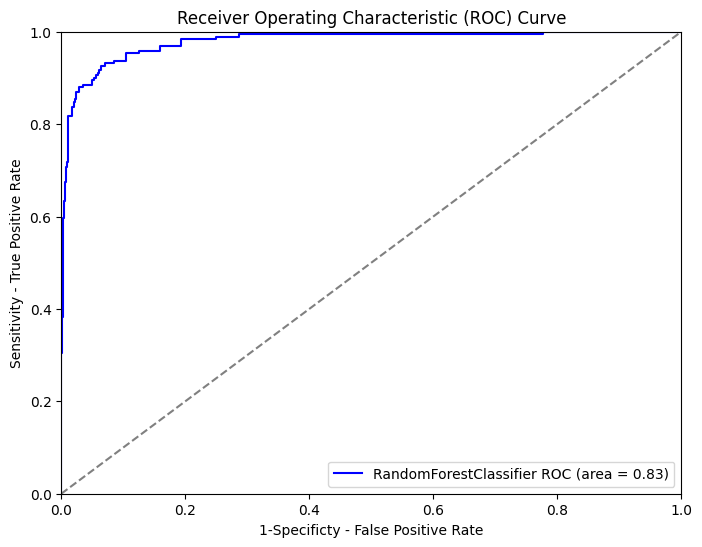

In [185]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

from sklearn.ensemble import RandomForestClassifier  # Ensure model is imported

auc_models = [
    {
        'label': 'RandomForestClassifier',
        'model': RandomForestClassifier(n_estimators=1000, min_samples_split=2, max_features=7, max_depth=15),
        'auc': 0.8319  # Keeping predefined AUC for labeling
    }
]

plt.figure(figsize=(8, 6))  # Move figure initialization outside the loop

for algo in auc_models:
    model = algo['model']
    model.fit(X_train, y_train)  # Ensure X_train and y_train are defined

    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])  # Ensure y_test and X_test are defined
    plt.plot(fpr, tpr, color='blue', label=f"{algo['label']} ROC (area = {algo['auc']:.2f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('1-Specificty - False Positive Rate')  # Corrected label from "Specificity"
plt.ylabel('Sensitivity - True Positive Rate')  # Corrected label from "Sensitivity"
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.savefig("auc.png")
plt.show()


### 83% of area is covered by Random Forest.